<a href="https://colab.research.google.com/github/mamun2519/ai-mi-lab/blob/main/end_to_end_simple_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


# Project 01

In [ ]:
# row data
raw_data = {
    'T_Shirt_Size': ['Medium', 'Small', 'Medium', 'Large', 'Small', 'Medium', 'Large', 'Large', 'Small', 'XL'],
    'Total_Spend': [1200, 800, 1150, 1600, 850, 1250, 1550, 9000, 780, 2100] #
}

df = pd.DataFrame(raw_data)
df

X = df[['T_Shirt_Size']]
y = df['Total_Spend']

# Train Test Split Code

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
display(X_train)
display(y_train)

,T_Shirt_Size
5,Medium
0,Medium
7,Large
2,Medium
9,XL
4,Small
3,Large
6,Large


,Total_Spend
5,1250
0,1200
7,9000
2,1150
9,2100
4,850
3,1600
6,1550


# Outlire Detection

In [ ]:
Q1 = df['Total_Spend'].quantile(0.25)
Q3 = df['Total_Spend'].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

df_clean = df[df['Total_Spend'] <= upper_bound].reset_index(drop=True)
display(df_clean)

,T_Shirt_Size,Total_Spend
0,Medium,1200
1,Small,800
2,Medium,1150
3,Large,1600
4,Small,850
5,Medium,1250
6,Large,1550
7,Small,780
8,XL,2100


# Feateres Enginning [Encoding]





In [ ]:
#
preprocessor = ColumnTransformer(
    transformers=[
        ('cat_encoder', OneHotEncoder(drop='first', sparse_output=False), ['T_Shirt_Size'])
    ],
    remainder='passthrough'
)
display(preprocessor)

ColumnTransformer(remainder='passthrough',
                  transformers=[('cat_encoder',
                                 OneHotEncoder(drop='first',
                                               sparse_output=False),
                                 ['T_Shirt_Size'])])

In [ ]:
# tain datar sate fit kora
X_train_processed = preprocessor.fit_transform(X_train)

# test data ke transfrom kora
X_test_processed = preprocessor.transform(X_test)
display(X_train_processed)


array([[1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 0.],
       [0., 0., 0.]])

# Linear Regression Model

In [ ]:
model = LinearRegression()
# fit the model
model.fit(X_train_processed,y_train)

LinearRegression()

In [ ]:
print("--- [STEP 5]: মডেল সাকসেসফুলি ট্রেইনড! ---")
print(f"মডেলের Intercept (Beta_0): {round(model.intercept_, 2)}")
print(f"মডেলের Slope (Beta_1): {np.round(model.coef_, 2)}")
print("\n" + "="*60 + "\n")

--- [STEP 5]: মডেল সাকসেসফুলি ট্রেইনড! ---
মডেলের Intercept (Beta_0): 4050.0
মডেলের Slope (Beta_1): [-2850. -3200. -1950.]




In [ ]:
# target colum pred
y_pred = model.predict(X_test_processed)
print(y_pred)

print(f"Mean Squared Error (MSE): {round(mean_squared_error(y_test, y_pred), 2)}")
print(f"R2 Score (মডেলের এক্যুরেসী): {round(r2_score(y_test, y_pred) * 100, 2)}% ")

[850. 850.]
Mean Squared Error (MSE): 3700.0
R2 Score (মডেলের এক্যুরেসী): -3600.0% 


# Project 02

In [ ]:

import warnings
warnings.filterwarnings("ignore")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [ ]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.linear_model import LinearRegression,SGDRegressor
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error

## Load DataSet

In [ ]:
df = pd.read_csv('bangladesh_student_performance.csv')
df.head()

,date,gender,age,address,famsize,Pstatus,M_Edu,F_Edu,M_Job,F_Job,relationship,smoker,tuition_fee,time_friends,ssc_result,hsc_result
0,29/04/2018,M,18,Rural,GT3,Together,3,2,At_home,Farmer,No,No,71672,4,4.22,3.72
1,29/04/2018,F,19,Rural,LE3,Apart,0,4,Other,Health,Yes,No,26085,5,3.47,2.62
2,29/04/2018,F,19,Rural,GT3,Together,0,3,Teacher,Services,No,No,40891,3,3.32,2.56
3,29/04/2018,F,19,Rural,LE3,Apart,2,3,At_home,Business,No,No,50600,2,4.57,4.17
4,29/04/2018,M,17,Rural,GT3,Together,1,1,At_home,Farmer,No,No,62458,2,4.50,3.94


In [ ]:
df.shape

(2018, 16)

In [ ]:
df.isnull().sum()

,0
date,0
gender,0
age,0
address,0
famsize,0
Pstatus,0
M_Edu,0
F_Edu,0
M_Job,0
F_Job,0


In [ ]:
df.columns

Index(['date', 'gender', 'age', 'address', 'famsize', 'Pstatus', 'M_Edu',
       'F_Edu', 'M_Job', 'F_Job', 'relationship', 'smoker', 'tuition_fee',
       'time_friends', 'ssc_result', 'hsc_result'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2018 entries, 0 to 2017
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          2018 non-null   object 
 1   gender        2018 non-null   object 
 2   age           2018 non-null   int64  
 3   address       2018 non-null   object 
 4   famsize       2018 non-null   object 
 5   Pstatus       2018 non-null   object 
 6   M_Edu         2018 non-null   int64  
 7   F_Edu         2018 non-null   int64  
 8   M_Job         2018 non-null   object 
 9   F_Job         2018 non-null   object 
 10  relationship  2018 non-null   object 
 11  smoker        2018 non-null   object 
 12  tuition_fee   2018 non-null   int64  
 13  time_friends  2018 non-null   int64  
 14  ssc_result    2018 non-null   float64
 15  hsc_result    2018 non-null   float64
dtypes: float64(2), int64(5), object(9)
memory usage: 252.4+ KB


# EDA

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'M_Edu'}>,
        <Axes: title={'center': 'F_Edu'}>],
       [<Axes: title={'center': 'tuition_fee'}>,
        <Axes: title={'center': 'time_friends'}>,
        <Axes: title={'center': 'ssc_result'}>],
       [<Axes: title={'center': 'hsc_result'}>, <Axes: >, <Axes: >]],
      dtype=object)

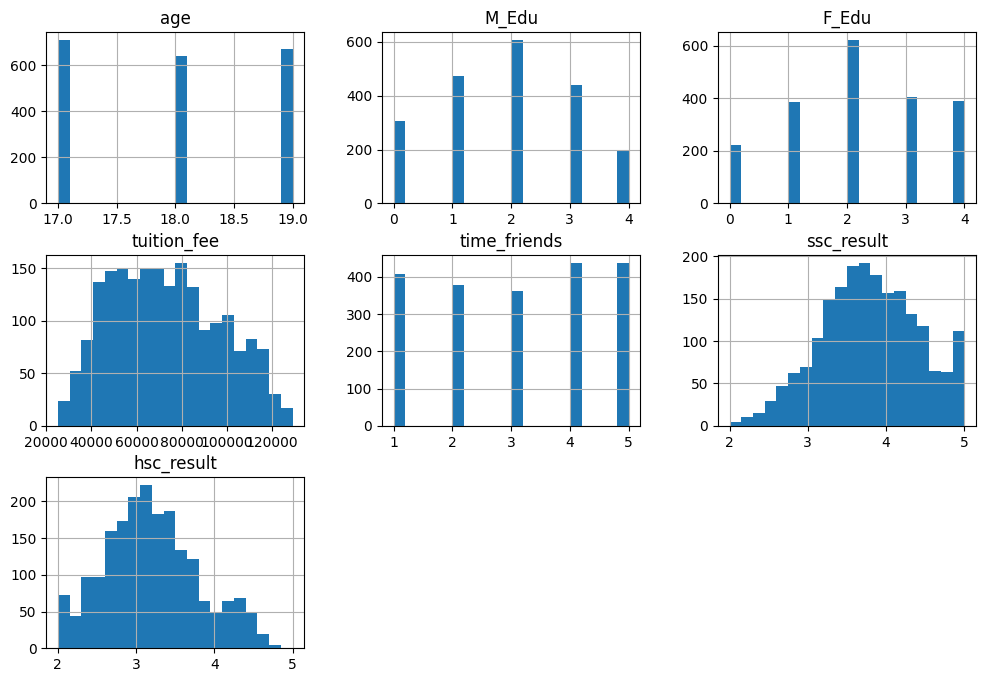

In [ ]:
df.hist(figsize = (12,8), bins = 20)

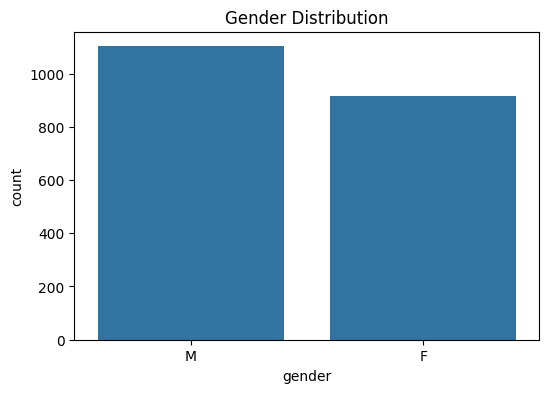

In [ ]:
# Gender Distribution
plt.figure(figsize = (6,4))
sns.countplot(
    data = df,
    x = "gender"
)

plt.title("Gender Distribution")
plt.show()

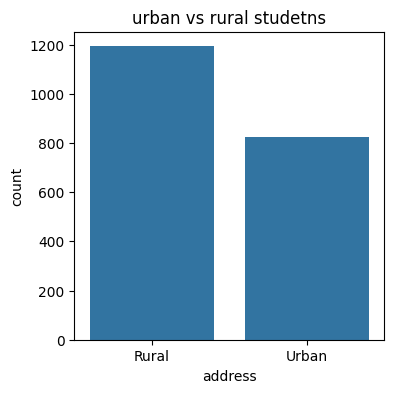

In [ ]:
# address Distribution
plt.figure(figsize = (4,4))
sns.countplot(data=df, x='address')

plt.title("urban vs rural studetns")
plt.show()

In [ ]:
df.columns

Index(['date', 'gender', 'age', 'address', 'famsize', 'Pstatus', 'M_Edu',
       'F_Edu', 'M_Job', 'F_Job', 'relationship', 'smoker', 'tuition_fee',
       'time_friends', 'ssc_result', 'hsc_result'],
      dtype='object')

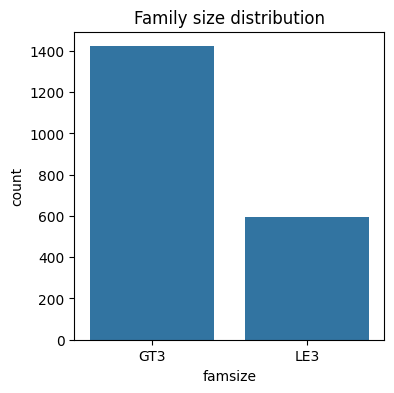

In [ ]:
# famsize Distribution
plt.figure(figsize=(4,4))
sns.countplot(data=df, x='famsize')
plt.title("Family size distribution")
plt.show()

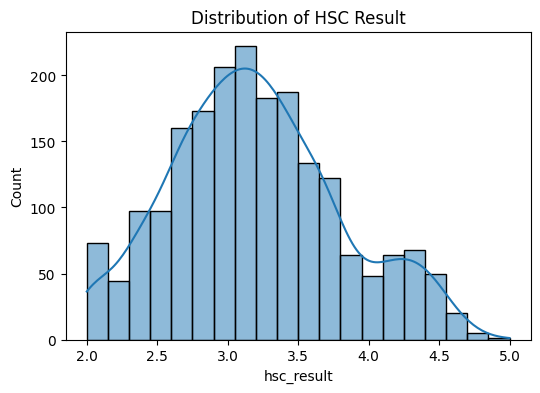

In [ ]:
# result distribation
plt.figure(figsize=(6,4))
sns.histplot(df['hsc_result'], bins = 20,
   kde= True )
plt.title("Distribution of HSC Result")
plt.show()

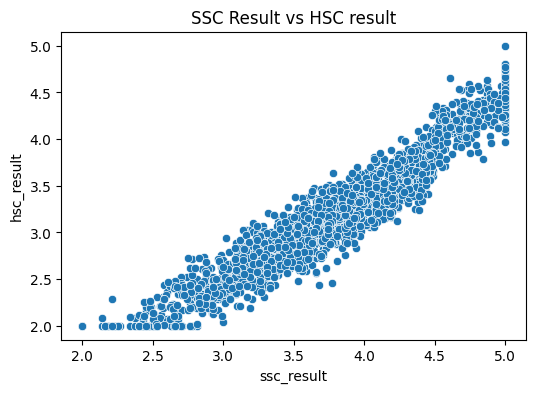

In [ ]:
# SSC VS HSC

plt.figure(figsize = (6,4) )

sns.scatterplot(
    data = df ,
    x = "ssc_result",
    y = "hsc_result"
)

plt.title("SSC Result vs HSC result")
plt.show()

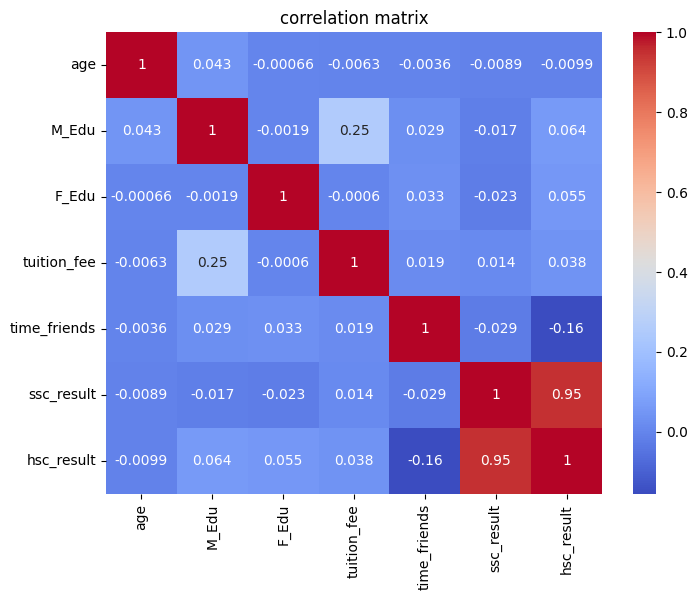

In [ ]:

# co-relation heatmap

plt.figure(figsize = (8,6) )

sns.heatmap(
    df.select_dtypes(include = np.number).corr(),
    annot = True,
    cmap = "coolwarm"
)

plt.title("correlation matrix")
plt.show()

# Feature and target

In [ ]:
X = df.drop(columns = ["hsc_result","date" ])
y = df['hsc_result']

In [ ]:
X

,gender,age,address,famsize,Pstatus,M_Edu,F_Edu,M_Job,F_Job,relationship,smoker,tuition_fee,time_friends,ssc_result
0,M,18,Rural,GT3,Together,3,2,At_home,Farmer,No,No,71672,4,4.22
1,F,19,Rural,LE3,Apart,0,4,Other,Health,Yes,No,26085,5,3.47
2,F,19,Rural,GT3,Together,0,3,Teacher,Services,No,No,40891,3,3.32
3,F,19,Rural,LE3,Apart,2,3,At_home,Business,No,No,50600,2,4.57
4,M,17,Rural,GT3,Together,1,1,At_home,Farmer,No,No,62458,2,4.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2013,M,18,Urban,GT3,Together,2,2,Teacher,Health,No,No,108426,2,3.57
2014,M,19,Urban,GT3,Together,0,3,Other,Teacher,Yes,No,100665,5,4.05
2015,M,18,Urban,GT3,Together,3,2,Services,Farmer,Yes,No,92291,1,3.93
2016,M,19,Rural,GT3,Together,0,2,At_home,Teacher,No,No,43926,3,3.34


In [ ]:
y

,hsc_result
0,3.72
1,2.62
2,2.56
3,4.17
4,3.94
...,...
2013,3.18
2014,3.13
2015,3.15
2016,2.83


In [ ]:
# Nemerical features
numeric_feature = X.select_dtypes( include = ["int64","float64"]).columns

In [ ]:
numeric_feature

Index(['age', 'M_Edu', 'F_Edu', 'tuition_fee', 'time_friends', 'ssc_result'], dtype='object')

In [ ]:
# Categorical features
categorical_features = X.select_dtypes(
    include = ["object"]
).columns

In [ ]:
categorical_features

Index(['gender', 'address', 'famsize', 'Pstatus', 'M_Job', 'F_Job',
       'relationship', 'smoker'],
      dtype='object')

In [ ]:
num_transformer = Pipeline(
    steps=[ ("imputer", SimpleImputer(strategy='median')),
        ("scaler", StandardScaler())]
)

In [ ]:
num_transformer

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

In [ ]:
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

In [ ]:

cat_transformer = Pipeline(
    steps = [
        ("imputer",SimpleImputer(strategy="most_frequent")),
        ("encoder",OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [ ]:
cat_transformer

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))])

In [ ]:
preprocessor = ColumnTransformer(
    transformers = [
        ("num",num_transformer,numeric_feature),
        ("cat",cat_transformer,categorical_features)
    ]
)

In [ ]:
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 Index(['age', 'M_Edu', 'F_Edu', 'tuition_fee', 'time_friends', 'ssc_result'], dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 Index(['gender', 'address', 'famsize', 'Pstatus', 'M_Job', 'F_Job',
       'relationship', 'smoker'],
      dtype='object'))])

In [ ]:
X_train, X_test , y_train, y_test = train_test_split(
    X,y, test_size = 0.20 , random_state = 42
)


In [ ]:
X_train

,gender,age,address,famsize,Pstatus,M_Edu,F_Edu,M_Job,F_Job,relationship,smoker,tuition_fee,time_friends,ssc_result
746,M,19,Rural,LE3,Together,2,2,Other,Services,No,No,49318,3,4.95
1381,M,17,Urban,GT3,Together,0,1,Health,Farmer,No,Yes,88032,5,2.68
240,F,17,Urban,GT3,Together,4,3,Other,Services,No,No,116230,4,3.75
1646,M,18,Urban,LE3,Apart,2,1,Other,Business,No,No,79334,3,3.70
1460,M,18,Rural,GT3,Apart,4,3,At_home,Farmer,No,No,80248,2,3.95
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1130,F,18,Rural,GT3,Together,2,2,At_home,Health,No,No,50003,1,3.83
1294,F,19,Urban,LE3,Together,2,3,At_home,Farmer,Yes,No,110895,2,3.30
860,F,19,Rural,GT3,Together,0,2,Health,Farmer,No,No,51576,1,5.00
1459,F,18,Rural,GT3,Together,2,4,Other,Services,No,No,45830,1,4.42


In [ ]:
X_test

,gender,age,address,famsize,Pstatus,M_Edu,F_Edu,M_Job,F_Job,relationship,smoker,tuition_fee,time_friends,ssc_result
1556,F,17,Rural,GT3,Together,1,1,At_home,Teacher,Yes,No,52743,1,3.88
526,M,19,Rural,GT3,Together,4,3,At_home,Business,No,No,58678,5,4.36
393,F,18,Urban,GT3,Together,2,1,Services,Services,No,No,115832,3,4.47
1789,M,17,Urban,GT3,Together,2,3,Health,Teacher,No,Yes,112781,1,4.43
433,M,19,Rural,LE3,Together,1,0,Teacher,Farmer,No,Yes,52481,4,4.71
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1112,M,17,Rural,GT3,Apart,1,4,Health,Teacher,No,No,60345,4,3.47
693,M,19,Urban,GT3,Together,1,2,Health,Business,No,No,85346,4,2.96
1494,F,18,Rural,LE3,Together,1,4,Teacher,Teacher,No,No,30638,1,3.76
921,M,19,Urban,GT3,Together,0,1,Teacher,Teacher,No,No,76804,2,4.18


# linear regression using pipeline

In [ ]:
lr_pipeline = Pipeline(
    steps = [
        ("preprocessor",preprocessor),
        ("model",LinearRegression())
    ]
)

lr_pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'M_Edu', 'F_Edu', 'tuition_fee', 'time_friends', 'ssc_result'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['gender', 'address', 'famsize', 'Pstatus', 'M_Job', 'F_Job',
       'relationship', 'smoker'],
      dtype='object'))])),
                ('model', LinearRegression())])

In [ ]:
lr_pipeline.predict(X_test)

#

array([3.22669684, 3.75113021, 3.83030552, 4.00812429, 3.90813125,
       3.33268499, 3.98238917, 2.54100569, 1.97989523, 3.27136765,
       3.67618639, 2.91974684, 3.23916997, 4.27745666, 3.03796909,
       2.67666797, 3.71635128, 3.45139645, 2.80448432, 2.96032266,
       2.82279738, 3.20360175, 2.99955789, 3.21756623, 1.89824069,
       2.58427455, 3.18535317, 3.82782921, 3.08736856, 3.94791665,
       2.41118168, 3.94402908, 4.31536621, 2.56485679, 3.1906842 ,
       3.26168549, 2.76183262, 3.65744712, 2.48538661, 2.6087985 ,
       3.07530752, 2.97249903, 3.73751782, 2.76766138, 2.17550874,
       3.06821563, 2.62014172, 2.6103055 , 4.03595945, 3.26038622,
       3.07496713, 3.45228036, 4.23442796, 3.63506638, 3.07127632,
       3.19967274, 3.29198851, 2.67393509, 3.81513176, 2.68699449,
       3.00552459, 2.76655742, 2.49090392, 4.43182742, 2.56047125,
       3.21025981, 3.96789734, 2.66949768, 3.03343159, 3.21841769,
       3.03009111, 2.722802  , 2.61470787, 3.63521455, 3.08131